## Evaluation

**Recommended run order:** Module 0 (working directory) → Module 1 (`rag`) → **Evaluation helpers** code cell → Representative queries → Comparisons 1–3 → optional wordcloud & `run_topk_tradeoff` plots.

### What each later cell does

- **Module 0 — Setup & path**
  - Set `cwd` to project root and add it to `sys.path` so `from src...` imports work.

- **Module 1 — Initialize RAG engine**
  - Create `rag = RAGEngine(...)` (loads chunks + initializes lexical retriever + generates neural embeddings).

- **Module 2 — Retrieval sanity check (Q1)**
  - Print **lexical** retrieved context.
  - Print **neural** retrieved context (with similarity).
  - Print a quick `compare_retrievers(...)` summary.

- **Module 3 Evaluation — Core helper functions**
  - Define shared utilities: token estimation, retrieval, summarization, generation (no-RAG / RAG-with-citations), judging (`judge_pairwise` with **KB-grounded** prompts when retrieval text is passed, plus `hallucination_severity` in JSON), and `overall_accuracy` (averages correctness/grounding/specificity/conciseness and an inverted hallucination term).

- **Representative queries (Q1–Q3)**
  - Define the 3 evaluation questions and build `queries = [(label, query), ...]`.

- **Comparison 1 — No-RAG vs Neural RAG**
  - For each query: Answer A = **no context**; Answer B = **neural retrieved context + citations**.
  - Judge A vs B and output a compact metrics list.

- **Comparison 2 — Lexical RAG vs Neural RAG**
  - For each query: Answer A = **lexical context + citations**; Answer B = **neural context + citations**.
  - Judge A vs B and also save `results` (including `lex_ctx`/`neu_ctx`) for visualization.

- **Comparison 3 — Raw vs Summarized context (Neural)**
  - For each query: Answer A = **raw neural context**; Answer B = **summarized neural context**.
  - Judge A vs B and report token reduction vs quality trade-off.

- **Visualization — Wordcloud (Q1 example)**
  - Use `results[0]` to plot **two wordclouds** (lexical vs neural). If `wordcloud` is missing, fall back to a bar chart.

- **Quality, Token-usage and top_k tradeoff**
  - Run `run_topk_tradeoff(...)` (see **Quality / top_k** cells) across multiple `top_k` values.
  - Plot **quality vs top_k**, **quality vs token-usage** and **token-usage vs top_k**.

### Notes

- If you see `parse_error` in judge outputs, it means the judge returned non-valid JSON (truncation or formatting); the notebook will continue running and record the raw output for inspection.
- For **fair factual scoring**, each comparison passes the same retrieved passages the generators used into `judge_pairwise` (or `shared_reference=True` for raw vs summary). Prefer a **larger `JUDGE_MODEL`** than `GEN_MODEL` when VRAM allows; `JUDGE_NUM_PREDICT` is set higher so JSON is not cut off.
- For stability on limited RAM/VRAM, prefer smaller models for **generation** and keep an eye on `num_ctx` when prompts include long excerpts.


## Module 0 — Setup

Set the working directory to the project root so imports like `from src.rag_engine import RAGEngine` work reliably.

In [1]:
import os, sys

# Project root (must contain `src/` and `data/`). Change if you cloned elsewhere.
os.chdir(r"e:\HKBU\COMP7125 Prompt Engineering\lab\HKBU_Study_Companion")
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: e:\HKBU\COMP7125 Prompt Engineering\lab\HKBU_Study_Companion


## Module 1 — Initialize RAG engine

Loads pre-chunked documents from `data/` (default file: `chunks_natural_500_50.jsonl` as in the code cell), then builds:
- **Lexical retriever** (keyword overlap)
- **Neural retriever** (Ollama embeddings + cosine similarity)

This step can take a few minutes the first time because embeddings are generated for all chunks.

In [2]:
%pip install numpy ollama pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from src.rag_engine import RAGEngine
rag = RAGEngine(chunk_file='chunks_natural_500_50.jsonl')


Initializing RAG Engine with chunks_natural_500_50.jsonl
Loaded 401 chunks from data\chunks_natural_500_50.jsonl
Loading cached embeddings from vector_db\chunks_natural_500_50_embeddings.npy
Initializing Lexical Retriever...
Initializing Neural Retriever (using cache)...
RAG Engine ready! (401 chunks)


## Module 2 — Retrieval sanity check (lexical vs neural)

Run one representative query and inspect the retrieved context snippets. This is a quick qualitative check before doing judge-based evaluation.

In [4]:
context, chunks = rag.lexical_search(
    "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?",
    top_k=3,
)
print(context)

[1] Source: D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\GenAI-AdvisoryGuidelines-Students.pdf (Page 1)
Content: CONFIDENTIAL – For Internal Use Only 
 
Advisory Guidelines Pertaining to the 
Use of Generative AI Tools in Assessed Assignment Tasks 
Summer 2025 | Summarised Version 
Purpose 
These guidelines align with HKBU’s University-wide Principles for the Use of Generative AI 
Tools in Teaching and Learning, and Assessment . They support ethical, transparent, and 
effective use of GenAI tools in assessed assignments, while upholding academic integrity and...

[2] Source: D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\COMP7930-2.pdf (Page 1)
Content: big data analytics; to develop proficiency in quantitative methods for big data analytics; to
conduct case studies demonstrating the applications of big
data analytics.
8. COURSE CONTENT
I. Overview of big data analytics
 - Big data: volume, velocity, variety, veracity, value
 - Challenges and opportunities
 

In [5]:
context, chunks = rag.neural_search(
    "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?",
    top_k=3,
)
print(context)

[1] [SYLLABUS] D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\COMP7045.pdf (Page 1) | Sim: 0.7422
Content: HONG KONG BAPTIST UNIVERSITY
COURSE OUTLINE
1. COURSE TITLE
Natural Language Processing and Large Language Models
2. COURSE CODE
COMP7045
3. NO. OF UNITS
3 Units
4. OFFERING DEPARTMENT
Master of Science in Data Analytics and Artificial Intelligence
5. PREREQUISITES
Basic knowledge in artificial intelligence
6. MEDIUM OF INSTRUCTION
E
7. AIMS & OBJECTIVES
To give students a solid background of natural language processing and Large Language...

[2] [HANDBOOK] D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\MSC International Student Guide 202406.pdf (Page 4) | Sim: 0.7273
Content: . Par1cipa1ng in local ac1vi1es, fes1vals and gatherings can also give you the opportunity to immerse yourself in the culture and make friends. 4. Health and Wellness • Safety Tips: Hong Kong is generally considered a safe city, but it is important to prac1ce cau1on and follow safet

In [6]:
result = rag.compare_retrievers(
    "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?",
    top_k=3,
)
print(result)

{'query': "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?", 'lexical': {'context': '[1] Source: D:\\Study lecture\\7125 Prompt\\HKBU_Study_Companion-main\\data\\GenAI-AdvisoryGuidelines-Students.pdf (Page 1)\nContent: CONFIDENTIAL – For Internal Use Only \n \nAdvisory Guidelines Pertaining to the \nUse of Generative AI Tools in Assessed Assignment Tasks \nSummer 2025 | Summarised Version \nPurpose \nThese guidelines align with HKBU’s University-wide Principles for the Use of Generative AI \nTools in Teaching and Learning, and Assessment . They support ethical, transparent, and \neffective use of GenAI tools in assessed assignments, while upholding academic integrity and...\n\n[2] Source: D:\\Study lecture\\7125 Prompt\\HKBU_Study_Companion-main\\data\\COMP7930-2.pdf (Page 1)\nContent: big data analytics; to develop proficiency in quantitative methods for big data analytics; to\nconduct case studies demonstrating the applic

## Evaluation (helpers)

Run the **code cell below** after Module 1 (`rag` is ready). It defines `judge_pairwise`, comparisons, and token helpers.


In [7]:
import json
import re
import ollama

from src.prompt_manager import PromptManager
from src.chat_logic import ChatLogic

# ---- Config  ----
# ChatLogic uses ollama.generate(model="gemma3:4b") for answers.
GEN_MODEL = "gemma3:1b"        # generation model (no-RAG / RAG answers)
# Prefer a *larger* model than GEN_MODEL for judging when VRAM allows (e.g. "gemma3:12b", "qwen3:8b"; there is no qwen3:9b on Ollama — use "qwen3.5:9b" if you want ~9B).
JUDGE_MODEL = "gemma3:4b"     # default judge; set to qwen3:8b etc. after `ollama pull` (empty outputs often mean wrong/missing model)
JUDGE_NUM_PREDICT = 768        # judge JSON includes extra fields; avoid truncation
# RAG answers from `answer_rag_via_chat` use ChatLogic -> `src/chat_logic.DEFAULT_GENERATION_MODEL` (gemma3:4b), not GEN_MODEL.
# GEN_MODEL is used for: no-RAG baseline, summarize_context, answer_with_context_via_pm, top_k tradeoff generation.

pm = PromptManager()
chat = ChatLogic(rag, pm)


def approx_tokens_from_chars(s: str) -> int:
    return max(1, int(len(s) / 4))


def retrieve_context(rag, retriever: str, query: str, top_k: int, max_chars: int = 2000):
    if retriever == "lexical":
        ctx, chunks = rag.lexical_search(query, top_k=top_k)
    elif retriever == "neural":
        ctx, chunks = rag.neural_search(query, top_k=top_k)
    else:
        raise ValueError("retriever must be 'lexical' or 'neural'")
    return ctx[:max_chars], chunks


def answer_no_rag(query: str, model: str = GEN_MODEL, num_predict: int = 600):
    # Match evaluation_basic.py style: use ollama.generate + real token counts.
    prompt = f"You are HKBU Study Companion.\nUser: {query}\nAssistant: "
    r = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": 0.0, "num_predict": num_predict},
    )
    return {
        "response": r.get("response", "").strip(),
        "prompt_tokens": r.get("prompt_eval_count", 0),
        "completion_tokens": r.get("eval_count", 0),
        "total_tokens": r.get("prompt_eval_count", 0) + r.get("eval_count", 0),
    }


def answer_rag_via_chat(query: str, retrieval_type: str, top_k: int = 3):
    # Isolated runs: do not append to chat history (avoids prior queries affecting later answers).
    return chat.process_query(
        query, retrieval_type=retrieval_type, top_k=top_k, update_history=False
    )


def summarize_context(ctx: str, model: str = GEN_MODEL, num_predict: int = 200):
    # Keep this as an optional token-efficiency technique.
    prompt = f"""Summarize the key facts from the context for answering the user question.
Return 5-8 bullet points.

[CONTEXT]
{ctx}
"""
    r = ollama.generate(
        model=model,
        prompt=prompt,
        options={"temperature": 0.0, "num_predict": num_predict},
    )
    return r.get("response", "").strip(), (r.get("prompt_eval_count", 0) + r.get("eval_count", 0))


def answer_with_context_via_pm(query: str, ctx: str, history=None, mode: str = "qa"):
    # Use assemble_prompt_simple so prompt is always a str (assemble_prompt returns (str, dict)).
    prompt = pm.assemble_prompt_simple(query=query, context_str=ctx, history=(history or []), mode=mode)
    r = ollama.generate(
        model=GEN_MODEL,
        prompt=prompt,
        options={"temperature": 0.0 if mode == "qa" else 0.7, "num_predict": 800, "top_p": 0.9, "top_k": 40},
    )
    return {
        "response": r.get("response", "").strip(),
        "total_tokens": r.get("prompt_eval_count", 0) + r.get("eval_count", 0),
    }


def answer_with_rag_and_citations(query: str, ctx: str, model: str = GEN_MODEL):
    # Backwards-compatible wrapper (older cells may still call this name).
    # Uses the basic framework prompt assembly + ollama.generate.
    return answer_with_context_via_pm(query, ctx, history=[], mode="qa")["response"]


def judge_pairwise(
    query: str,
    answer_a: str,
    answer_b: str,
    model: str = JUDGE_MODEL,
    num_ctx: int = 1024,
    num_predict=None,
    reference_context=None,
    reference_context_a=None,
    reference_context_b=None,
    shared_reference: bool = False,
):
    """Pairwise judge with optional KB grounding.

    - **No-RAG vs RAG**: ``reference_context`` = neural retrieval for B; ``shared_reference=False``.
    - **Lexical vs Neural**: ``reference_context_a`` and ``reference_context_b``.
    - **Raw vs summarized**: ``reference_context`` = raw neural excerpts; ``shared_reference=True``.
    """
    if num_predict is None:
        num_predict = JUDGE_NUM_PREDICT

    def _truncate(s: str, max_len: int = 8000) -> str:
        s = s.strip()
        if len(s) > max_len:
            return s[:max_len] + "\n...[truncated]"
        return s

    ref_block = ""
    label_a = "[ANSWER A]"
    label_b = "[ANSWER B]"

    if reference_context_a and reference_context_b:
        # Two long refs + answers + JSON instructions can exceed context; cap each side.
        ra = _truncate(reference_context_a, 4500)
        rb = _truncate(reference_context_b, 4500)
        num_ctx = max(num_ctx, 8192)
        ref_block = (
            "\nGROUNDING RULES:\n"
            "- Answer A used LEXICAL retrieval; Answer B used NEURAL retrieval.\n"
            "- Each REFERENCE block is the retrieved context used for that answer (same top_k as generation).\n"
            "- Score correctness and grounding for each answer against ITS OWN reference.\n"
            "- Prefer the answer whose claims are better supported by its reference; penalize fabricated dates/deadlines.\n\n"
            "[REFERENCE FOR ANSWER A (lexical)]\n"
            + ra
            + "\n\n[REFERENCE FOR ANSWER B (neural)]\n"
            + rb
            + "\n\n"
        )
        label_a = "[ANSWER A - RAG lexical]"
        label_b = "[ANSWER B - RAG neural]"
    elif reference_context:
        ref = _truncate(reference_context)
        num_ctx = max(num_ctx, 8192)
        if shared_reference:
            ref_block = (
                "\nGROUNDING RULES:\n"
                "- Both answers were derived from the REFERENCE EXCERPTS (same retrieval).\n"
                "- Answer A used full/raw context; Answer B used a summary of that material.\n"
                "- Judge factual correctness of BOTH against the EXCERPTS; penalize hallucinations.\n\n"
                "[REFERENCE EXCERPTS (knowledge base)]\n"
                + ref
                + "\n\n"
            )
            label_a = "[ANSWER A - raw context]"
            label_b = "[ANSWER B - summarized context]"
        else:
            ref_block = (
                "\nGROUNDING RULES:\n"
                "- Answer A was produced WITHOUT the passages below (no-RAG).\n"
                "- Answer B used retrieval; the passages below are the same context used for Answer B.\n"
                "- For factual questions (dates, deadlines, policies, course rules), treat the EXCERPTS as primary evidence.\n"
                "- Prefer Answer B when its claims match the excerpts; penalize Answer A for confident guesses or contradictions.\n"
                "- Do not let fluency alone outweigh factual alignment with the excerpts.\n\n"
                "[REFERENCE EXCERPTS (same retrieval as Answer B)]\n"
                + ref
                + "\n\n"
            )
            label_a = "[ANSWER A - no-RAG baseline]"
            label_b = "[ANSWER B - neural RAG]"

    prompt = f"""You are an impartial judge.

User question:
{query}{ref_block}
Compare two answers.

{label_a}
{answer_a}

{label_b}
{answer_b}

Score EACH answer (1-5) on:
- correctness (question + REFERENCE when provided)
- grounding (penalize unsupported claims, invented dates/deadlines, or contradictions with REFERENCE)
- specificity
- conciseness
- hallucination_severity (1 = none; 5 = severe fabrication)

Return JSON only with schema:
{{
  "A": {{"correctness": <int>, "grounding": <int>, "specificity": <int>, "conciseness": <int>, "hallucination_severity": <int>}},
  "B": {{"correctness": <int>, "grounding": <int>, "specificity": <int>, "conciseness": <int>, "hallucination_severity": <int>}},
  "winner": "A"|"B"|"Tie",
  "reasons": ["<reason1>","<reason2>","<reason3>"]
}}
"""
    chat_opts = {"temperature": 0, "num_ctx": num_ctx, "num_predict": num_predict}
    r = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        format="json",
        options=chat_opts,
        keep_alive=0,
    )
    msg = r.get("message") or {}
    text = (msg.get("content") or "").strip()
    # Some models return empty body with format=json (unsupported or context blow-up). Retry without it.
    if not text:
        r = ollama.chat(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            options=chat_opts,
            keep_alive=0,
        )
        msg = r.get("message") or {}
        text = (msg.get("content") or "").strip()
    if not text:
        return {
            "parse_error": True,
            "raw": "",
            "empty_ollama_content": True,
            "ollama": {
                "done": r.get("done"),
                "done_reason": r.get("done_reason"),
                "model": r.get("model"),
                "prompt_eval_count": r.get("prompt_eval_count"),
                "eval_count": r.get("eval_count"),
            },
            "prompt_chars": len(prompt),
            "hint": "No text from Ollama: prompt may exceed num_ctx, format=json may fail on this model, or GPU OOM. Lower max_chars in retrieve_context, raise num_ctx, or change JUDGE_MODEL.",
        }
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{[\s\S]*\}", text)
        if not m:
            return {"parse_error": True, "raw": text, "done_reason": r.get("done_reason")}
        candidate = m.group(0)
        try:
            return json.loads(candidate)
        except Exception:
            return {"parse_error": True, "raw": text, "raw_candidate": candidate, "done_reason": r.get("done_reason")}


def overall_accuracy(score_dict: dict):
    """Mean score; includes inverted hallucination_severity as faithfulness (higher is better)."""
    try:
        base = [
            int(score_dict["correctness"]),
            int(score_dict["grounding"]),
            int(score_dict["specificity"]),
            int(score_dict["conciseness"]),
        ]
        if "hallucination_severity" in score_dict:
            hs = max(1, min(5, int(score_dict["hallucination_severity"])))
            base.append(6 - hs)
        return sum(base) / len(base)
    except Exception:
        return None


### Comparison 1 — No-RAG vs Neural RAG

- **Goal**: quantify the benefit of adding retrieved context.
- **Setup**: Answer A = direct LLM answer (**no context**); Answer B = **neural retriever** context + citation-style answer.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list (overall_accuracy + winner).

In [8]:
# ---- Representative queries ----
# Grounded in data/ (chunks_natural_500_50.jsonl). Types: Q1 factoid, Q2 policy, Q3 planning (must cite KB; flag unknowns).
Q1 = (
    "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?"
)
Q2 = (
    "According to HKBU's Policy for the Assessment of Student Learning, when should students receive "
    "information about assessment procedures, deadlines, and penalties for late submission?"
)
Q3 = (
    "Propose a 2-week study plan for COMP7125 (with two other DAAI courses). "
    "Ground dates, venues, and assessment facts in the retrieved context; mark what is not in the corpus and needs official verification."
)

queries = [
    ("Q1", Q1),
    ("Q2", Q2),
    ("Q3", Q3),
]

queries

[('Q1',
  "What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?"),
 ('Q2',
  "According to HKBU's Policy for the Assessment of Student Learning, when should students receive information about assessment procedures, deadlines, and penalties for late submission?"),
 ('Q3',
  'Propose a 2-week study plan for COMP7125 (with two other DAAI courses). Ground dates, venues, and assessment facts in the retrieved context; mark what is not in the corpus and needs official verification.')]

In [9]:
# ---- No-RAG vs Neural RAG ----

no_rag_vs_neural_rag = []

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # No-RAG (ollama.generate) + real token counts
    no_rag = answer_no_rag(query)

    # RAG Neural (ChatLogic unified interface)
    rag_neu = answer_rag_via_chat(query, retrieval_type="neural", top_k=3)

    # Same neural retrieval the judge should use as ground truth for factual scoring
    neural_ctx_for_judge, _ = rag.neural_search(query, top_k=3)

    print("\n=== ANSWER A (no-RAG) ===\n", no_rag["response"])
    print(f"No-RAG tokens: {no_rag['total_tokens']}")

    print("\n=== ANSWER B (RAG-Neural) ===\n", rag_neu["response"])
    print(f"RAG-Neural tokens: {rag_neu['total_tokens']} | Cited: {rag_neu['cited_docs'][:2]}...")

    # Judge (grounded: includes same retrieval excerpts as Answer B)
    verdict = judge_pairwise(
        query,
        no_rag["response"],
        rag_neu["response"],
        reference_context=neural_ctx_for_judge,
    )
    print("\n=== JUDGE (no-RAG vs RAG-Neural) ===")
    print(verdict)

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        no_rag_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "no_rag_tokens": no_rag["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
            }
        )
    else:
        no_rag_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "no_rag_tokens": no_rag["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
                "parse_error": True,
                "raw_verdict": verdict,
            }
        )

no_rag_vs_neural_rag


Q1: What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?

=== ANSWER A (no-RAG) ===
 Okay, let's dive into the HKBU Advisory Guidelines on using Generative AI tools in assessed assignments. Here’s a breakdown of the stated purpose, as outlined in the guidelines:

**The stated purpose of the guidelines is to provide clear guidance and best practices for students to effectively and ethically utilize Generative AI tools (like ChatGPT, Bard, etc.) within their assignments while upholding academic integrity and ensuring a fair assessment process.**

Essentially, the guidelines aim to help students understand:

* **What’s Allowed:** The types of assignments where generative AI can be used (e.g., brainstorming, outlining, drafting, editing – but *not* generating the entire assignment).
* **What’s Not Allowed:**  Specific tasks that are considered plagiarism or academic dishonesty (e.g., submitting AI-generated content as your own work

[{'label': 'Q1',
  'A_overall_accuracy': 4.6,
  'B_overall_accuracy': 4.8,
  'winner': 'B',
  'no_rag_tokens': 381,
  'rag_neural_tokens': 766},
 {'label': 'Q2',
  'A_overall_accuracy': 4.2,
  'B_overall_accuracy': 4.4,
  'winner': 'B',
  'no_rag_tokens': 552,
  'rag_neural_tokens': 786},
 {'label': 'Q3',
  'A_overall_accuracy': 3.8,
  'B_overall_accuracy': 4.8,
  'winner': 'B',
  'no_rag_tokens': 672,
  'rag_neural_tokens': 2490}]

### Comparison 2 — Lexical RAG vs Neural RAG

- **Goal**: compare retrievers while keeping the generator the same.
- **Setup**: Answer A = **lexical** context + citations; Answer B = **neural** context + citations.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list.

This cell also saves `results` (with `lex_ctx`/`neu_ctx`) for the later **Q1 wordcloud** visualization.

In [10]:
# ---- Lexical RAG vs Neural RAG (basic unified interface) ----

lexical_vs_neural_rag = []
results = []  # keep contexts for downstream wordcloud cell

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # RAG Lexical / Neural via ChatLogic
    rag_lex = answer_rag_via_chat(query, retrieval_type="lexical", top_k=3)
    rag_neu = answer_rag_via_chat(query, retrieval_type="neural", top_k=3)

    lex_ctx, _ = retrieve_context(rag, "lexical", query, top_k=3, max_chars=8000)
    neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=3, max_chars=8000)

    print("\n=== ANSWER A (RAG-Lexical) ===\n", rag_lex["response"])
    print(f"RAG-Lexical tokens: {rag_lex['total_tokens']} | Cited: {rag_lex['cited_docs'][:2]}...")

    print("\n=== ANSWER B (RAG-Neural) ===\n", rag_neu["response"])
    print(f"RAG-Neural tokens: {rag_neu['total_tokens']} | Cited: {rag_neu['cited_docs'][:2]}...")

    verdict = judge_pairwise(
        query,
        rag_lex["response"],
        rag_neu["response"],
        reference_context_a=lex_ctx,
        reference_context_b=neu_ctx,
    )
    print("\n=== JUDGE (RAG-Lexical vs RAG-Neural) ===")
    print(verdict)

    results.append({"label": label, "lex_ctx": lex_ctx, "neu_ctx": neu_ctx})

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        lexical_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "rag_lexical_tokens": rag_lex["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
            }
        )
    else:
        lexical_vs_neural_rag.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "rag_lexical_tokens": rag_lex["total_tokens"],
                "rag_neural_tokens": rag_neu["total_tokens"],
                "parse_error": True,
            }
        )

lexical_vs_neural_rag


Q1: What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?

=== ANSWER A (RAG-Lexical) ===
 The stated purpose of HKBU’s Advisory Guidelines on using Generative AI tools in assessed assignments is to support ethical, transparent, and effective use of GenAI tools while upholding academic integrity [Source: D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\GenAI-AdvisoryGuidelines-Students.pdf, Page 1]. 

[Source: D:\Study lecture\7125 Prompt\HKBU_Study_Companion-main\data\GenAI-AdvisoryGuidelines-Students.pdf, Page 1]
RAG-Lexical tokens: 863 | Cited: ['D:\\Study lecture\\7125 Prompt\\HKBU_Study_Companion-main\\data\\GenAI-AdvisoryGuidelines-Students.pdf', 'D:\\Study lecture\\7125 Prompt\\HKBU_Study_Companion-main\\data\\COMP7930-2.pdf']...

=== ANSWER B (RAG-Neural) ===
 The stated purpose of HKBU’s Advisory Guidelines on using Generative AI tools in assessed assignments is to provide students with guidance on appropriat

[{'label': 'Q1',
  'A_overall_accuracy': 4.8,
  'B_overall_accuracy': 3.8,
  'winner': 'A',
  'rag_lexical_tokens': 863,
  'rag_neural_tokens': 766},
 {'label': 'Q2',
  'A_overall_accuracy': 4.8,
  'B_overall_accuracy': 3.8,
  'winner': 'A',
  'rag_lexical_tokens': 794,
  'rag_neural_tokens': 786},
 {'label': 'Q3',
  'A_overall_accuracy': 4.2,
  'B_overall_accuracy': 3.6,
  'winner': 'A',
  'rag_lexical_tokens': 2590,
  'rag_neural_tokens': 2514}]

### Comparison 3 — Raw context vs Summarized context (Neural)

- **Goal**: test a simple context-optimization strategy.
- **Setup**: Answer A = neural retrieved **raw** context; Answer B = neural context after **summarization**.
- **Output**: per query, print both answers + judge JSON, and a compact metrics list (including token usage before/after summarization).

In [11]:
# ---- Raw vs Summarized context (Neural) ----

raw_vs_summarized_neural = []

for label, query in queries:
    print("\n" + "=" * 80)
    print(f"{label}: {query}")
    print("=" * 80)

    # Retrieval (neural)
    neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=3, max_chars=2000)
    sum_ctx, sum_tokens = summarize_context(neu_ctx)

    # Answers via PromptManager (context-only + citations rules)
    ans_raw = answer_with_context_via_pm(query, neu_ctx, history=[], mode="qa")
    ans_sum = answer_with_context_via_pm(query, sum_ctx, history=[], mode="qa")

    print("\n--- Token usage (real + approx) ---")
    print("raw ctx approx tokens≈", approx_tokens_from_chars(neu_ctx))
    print("sum ctx approx tokens≈", approx_tokens_from_chars(sum_ctx), "| summarize tokens:", sum_tokens)
    print("gen(raw) tokens:", ans_raw["total_tokens"], "| gen(sum) tokens:", ans_sum["total_tokens"])

    verdict = judge_pairwise(
        query,
        ans_raw["response"],
        ans_sum["response"],
        reference_context=neu_ctx,
        shared_reference=True,
    )

    print("\n=== ANSWER A (raw ctx) ===\n", ans_raw["response"])
    print("\n=== ANSWER B (summarized ctx) ===\n", ans_sum["response"])
    print("\n=== JUDGE (raw vs summarized) ===")
    print(verdict)

    if isinstance(verdict, dict) and not verdict.get("parse_error"):
        a = verdict.get("A", {})
        b = verdict.get("B", {})
        raw_vs_summarized_neural.append(
            {
                "label": label,
                "A_overall_accuracy": round(overall_accuracy(a) or 0, 2) if overall_accuracy(a) is not None else None,
                "B_overall_accuracy": round(overall_accuracy(b) or 0, 2) if overall_accuracy(b) is not None else None,
                "winner": verdict.get("winner"),
                "raw_ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "sum_ctx_tokens_approx": approx_tokens_from_chars(sum_ctx),
                "summarize_tokens": sum_tokens,
                "gen_raw_tokens": ans_raw["total_tokens"],
                "gen_sum_tokens": ans_sum["total_tokens"],
            }
        )
    else:
        raw_vs_summarized_neural.append(
            {
                "label": label,
                "A_overall_accuracy": None,
                "B_overall_accuracy": None,
                "winner": None,
                "raw_ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "sum_ctx_tokens_approx": approx_tokens_from_chars(sum_ctx),
                "summarize_tokens": sum_tokens,
                "gen_raw_tokens": ans_raw["total_tokens"],
                "gen_sum_tokens": ans_sum["total_tokens"],
                "parse_error": True,
            }
        )

raw_vs_summarized_neural


Q1: What is the stated purpose of HKBU's Advisory Guidelines on using Generative AI tools in assessed assignments?

--- Token usage (real + approx) ---
raw ctx approx tokens≈ 438
sum ctx approx tokens≈ 220 | summarize tokens: 721
gen(raw) tokens: 782 | gen(sum) tokens: 745

=== ANSWER A (raw ctx) ===
 The provided context does not explicitly state the purpose of HKBU’s Advisory Guidelines on using Generative AI tools in assessed assignments. The context focuses on data security and privacy concepts and techniques, and the application of cryptographic tools for data security and privacy protection. It doesn’t address the use of generative AI.

Therefore, I cannot answer your question based on the provided context.

=== ANSWER B (summarized ctx) ===
 The advisory guidelines on using Generative AI tools in assessed assignments at HKBU emphasize ensuring academic integrity and responsible use of these tools. Specifically, the guidelines aim to prevent students from relying on AI to comple

[{'label': 'Q1',
  'A_overall_accuracy': 2.0,
  'B_overall_accuracy': 4.6,
  'winner': 'B',
  'raw_ctx_tokens_approx': 438,
  'sum_ctx_tokens_approx': 220,
  'summarize_tokens': 721,
  'gen_raw_tokens': 782,
  'gen_sum_tokens': 745},
 {'label': 'Q2',
  'A_overall_accuracy': 4.8,
  'B_overall_accuracy': 3.8,
  'winner': 'A',
  'raw_ctx_tokens_approx': 474,
  'sum_ctx_tokens_approx': 257,
  'summarize_tokens': 722,
  'gen_raw_tokens': 789,
  'gen_sum_tokens': 506},
 {'label': 'Q3',
  'A_overall_accuracy': 4.6,
  'B_overall_accuracy': 3.4,
  'winner': 'A',
  'raw_ctx_tokens_approx': 450,
  'sum_ctx_tokens_approx': 261,
  'summarize_tokens': 713,
  'gen_raw_tokens': 1523,
  'gen_sum_tokens': 1002}]

**Wordcloud comparison (lexical vs neural)**

Requires **Comparison 2** to have run so `results` is populated (`results[0]` is Q1).

In [14]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [21]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


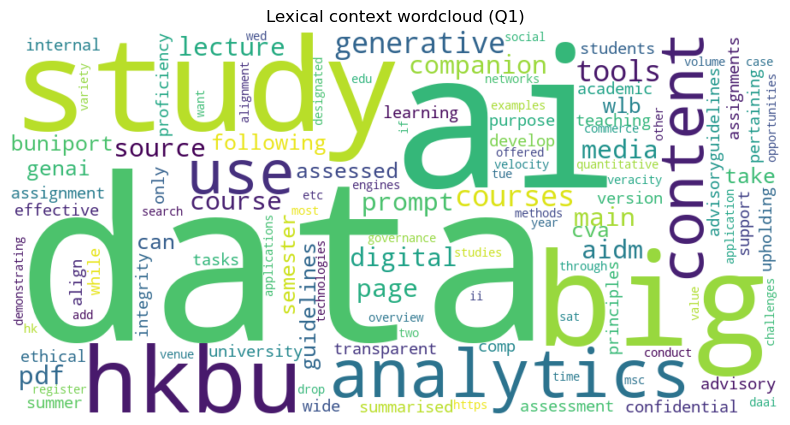

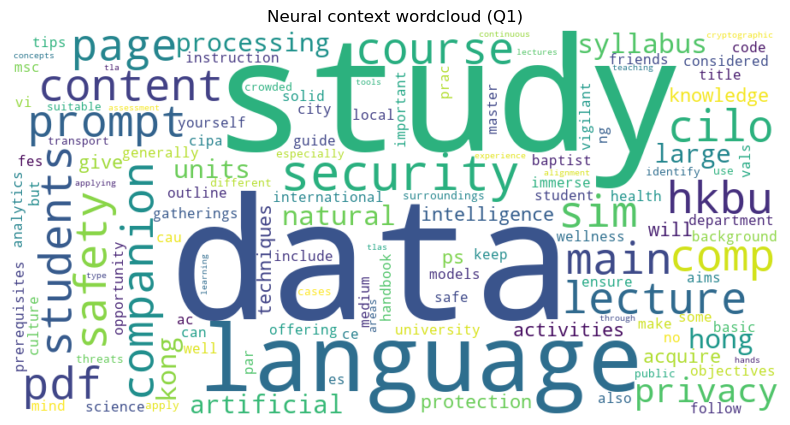

In [22]:
# Creates two wordclouds for a chosen query (default: Q1).

import matplotlib.pyplot as plt
from collections import Counter


def _clean_words(text: str):
    text = text.lower()
    words = re.findall(r"[a-z]{2,}", text)
    stop = {
        "the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
    "of", "to", "for", "and", "or", "in", "on", "at", "with", "by", "about",
    "what", "how", "why", "when", "where", "which", "who", "whom", "whose",
    "this", "that", "these", "those", "it", "they", "we", "you", "he", "she",
    "it", "them", "us", "him", "her", "its", "their", "our", "your"
    }
    return [w for w in words if w not in stop]


def plot_wordcloud_or_bars(title: str, text: str):
    words = _clean_words(text)
    freq = Counter(words)

    try:
        from wordcloud import WordCloud

        wc = WordCloud(width=900, height=450, background_color="white").generate_from_frequencies(freq)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()
    except Exception:
        top = freq.most_common(15)
        labels = [x[0] for x in top]
        vals = [x[1] for x in top]
        plt.figure(figsize=(10, 4))
        plt.bar(labels, vals)
        plt.xticks(rotation=45, ha="right")
        plt.title(title + " (top words)")
        plt.tight_layout()
        plt.show()


# Use Q1 results for visualization
r0 = results[0]
plot_wordcloud_or_bars("Lexical context wordcloud (Q1)", r0["lex_ctx"])
plot_wordcloud_or_bars("Neural context wordcloud (Q1)", r0["neu_ctx"])


## Quality, Token usage and Top_k tradeoff

This section evaluates how different `top_k` values affect:
- **Token usage** (approx context tokens)
- **Quality** (LLM-as-judge per-criterion scores + computed overall)

Run this after the main 3-query pipeline.


In [17]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
# --- Optional: top_k tradeoff (minimal version) ---
# Goal: produce data for three plots:
# - quality vs token-usage
# - quality vs top_k
# - token-usage vs top_k

import pandas as pd


def run_topk_tradeoff(rag, query: str, top_ks=(1, 2, 3, 4, 5), max_chars_context: int = 3000):
    rows = []

    for k in map(int, top_ks):
        lex_ctx, _ = retrieve_context(rag, "lexical", query, top_k=k, max_chars=max_chars_context)
        neu_ctx, _ = retrieve_context(rag, "neural", query, top_k=k, max_chars=max_chars_context)

        ans_lex = answer_with_rag_and_citations(query, lex_ctx, model=GEN_MODEL)
        ans_neu = answer_with_rag_and_citations(query, neu_ctx, model=GEN_MODEL)

        verdict = judge_pairwise(
            query,
            ans_lex,
            ans_neu,
            model=JUDGE_MODEL,
            reference_context_a=lex_ctx,
            reference_context_b=neu_ctx,
        )

        if isinstance(verdict, dict) and not verdict.get("parse_error"):
            a = verdict.get("A", {})
            b = verdict.get("B", {})
            lex_overall = overall_accuracy(a)
            neu_overall = overall_accuracy(b)
        else:
            lex_overall = None
            neu_overall = None

        rows.append(
            {
                "retriever": "lexical",
                "top_k": k,
                "ctx_tokens_approx": approx_tokens_from_chars(lex_ctx),
                "overall_accuracy": None if lex_overall is None else round(float(lex_overall), 2),
            }
        )
        rows.append(
            {
                "retriever": "neural",
                "top_k": k,
                "ctx_tokens_approx": approx_tokens_from_chars(neu_ctx),
                "overall_accuracy": None if neu_overall is None else round(float(neu_overall), 2),
            }
        )

    return pd.DataFrame(rows).sort_values(["retriever", "top_k"]).reset_index(drop=True)


tradeoff_df = run_topk_tradeoff(rag, query=Q1, top_ks=(1, 2, 3, 4, 5), max_chars_context=3000)
tradeoff_df


,retriever,top_k,ctx_tokens_approx,overall_accuracy
0,lexical,1,145,4.8
1,lexical,2,287,4.8
2,lexical,3,441,4.8
3,lexical,4,577,4.8
4,lexical,5,730,4.6
5,neural,1,141,1.6
6,neural,2,290,1.0
7,neural,3,438,1.4
8,neural,4,599,2.0
9,neural,5,750,1.8


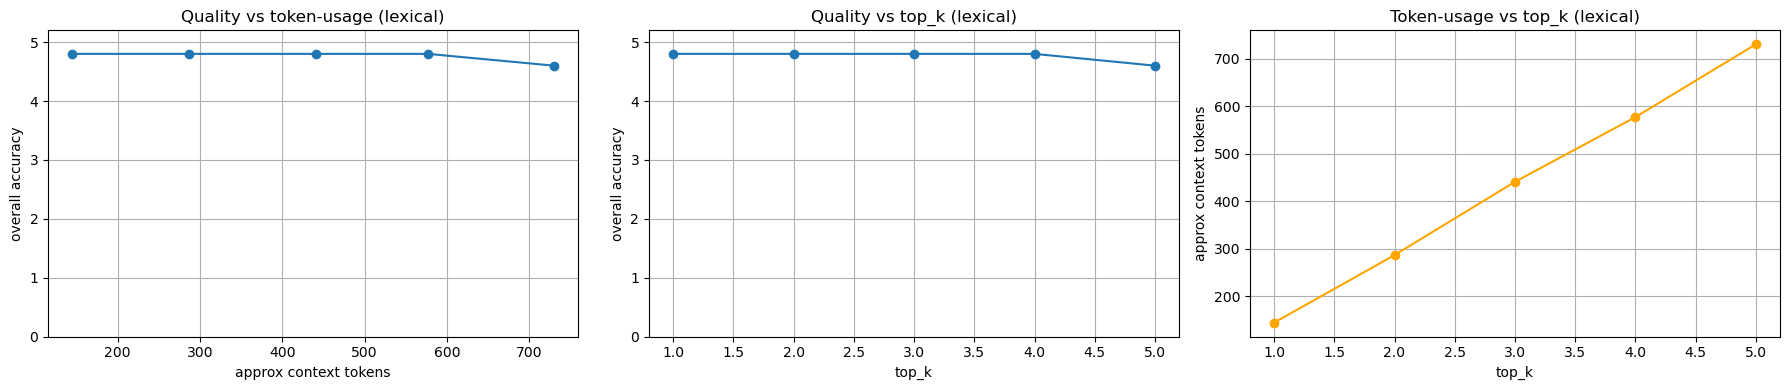

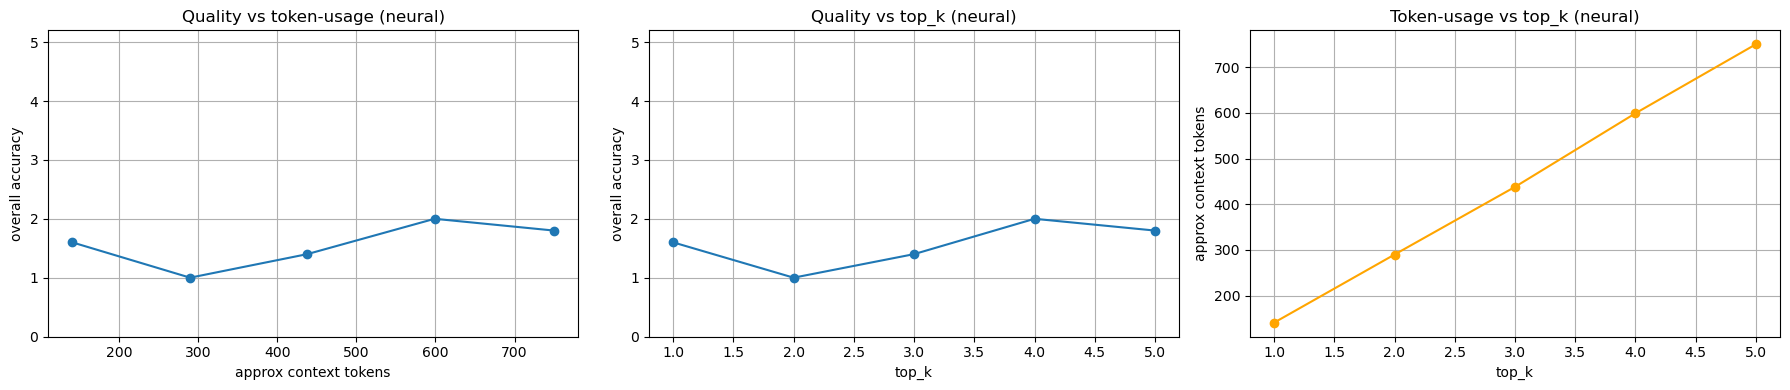

In [31]:
import matplotlib.pyplot as plt

# Uses `tradeoff_df` from the previous cell.

def plot_tradeoff_row(df, retriever: str):
    sub = df[df["retriever"] == retriever].sort_values("top_k")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # 1) quality vs token-usage
    axes[0].plot(sub["ctx_tokens_approx"], sub["overall_accuracy"], marker="o")
    axes[0].set_title(f"Quality vs token-usage ({retriever})")
    axes[0].set_xlabel("approx context tokens")
    axes[0].set_ylabel("overall accuracy")
    axes[0].set_ylim(0, 5.2)
    axes[0].grid(True)

    # 2) quality vs top_k
    axes[1].plot(sub["top_k"], sub["overall_accuracy"], marker="o")
    axes[1].set_title(f"Quality vs top_k ({retriever})")
    axes[1].set_xlabel("top_k")
    axes[1].set_ylabel("overall accuracy")
    axes[1].set_ylim(0, 5.2)
    axes[1].grid(True)

    # 3) token-usage vs top_k
    axes[2].plot(sub["top_k"], sub["ctx_tokens_approx"], marker="o", color="orange")
    axes[2].set_title(f"Token-usage vs top_k ({retriever})")
    axes[2].set_xlabel("top_k")
    axes[2].set_ylabel("approx context tokens")
    axes[2].grid(True)

    fig.tight_layout()
    plt.show()


plot_tradeoff_row(tradeoff_df, "lexical")
plot_tradeoff_row(tradeoff_df, "neural")
